In [50]:
# from sys import displayhook
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import glob
import math
from matplotlib import pyplot as plt

In [19]:
file_loc = "storage/COUP/run9/[0-9]*.csv"

In [72]:
def log_laplace_single(t, k_0, alpha=1):
    if t < k_0:
        return 1 - 0.5 * (t / k_0) ** alpha
    else:
        return 0.5 * (k_0 / t) ** alpha

utils = []
fs = []
ucbs = []
lcbs = []
k_0 = 250

for file in sorted(glob.glob(file_loc, recursive=False)):
    print(file)
    df = pd.read_csv(file)
    # display(df)

    u_hat = sum(log_laplace_single(t, k_0) for t in df["runtime"]) / len(df)
    utils.append(u_hat)

    n = len(glob.glob(file_loc, recursive=False))
    m = len(df)
    delta = 0.05
    alpha_i = math.sqrt(math.log(26.71 * n**2 * m**2 * (math.log2(k_0) + 1)**2 / delta) / 2 / m)

     # alpha_i = self.alpha_p(p, n_p, m[i], k[i], delta)
    # len(self.configs[i]['completed']) / len(self.configs[i]['runtimes'])
    counts = df["status"].value_counts()
    # print(counts)
    # print(len(df))
    total_instances = len(df)
    n_completed = total_instances - counts["TIMEOUT"]
    print(file)
    print(counts["TIMEOUT"])
    print(total_instances)
    # breakpoint()
    f_hat_i = n_completed / total_instances
    ucb_i = 1
    lcb_i = 0
    UCB = min(u_hat + (1 - log_laplace_single(k_0, k_0)) * alpha_i, ucb_i)
    LCB = max(u_hat - alpha_i - log_laplace_single(k_0, k_0) * (1 - f_hat_i), lcb_i)

    fs.append(f_hat_i)
    ucbs.append(float(UCB))
    lcbs.append(float(LCB))

    # print(u_hat)
    # print()

    # F_hat[i] = sum([1 if t < k[i] else 0 for t in runtimes]) / m[i]
    # U_hat[i] = sum(utility(t) for t in runtimes) / m[i]

    # F_hat[i] = sum([1 if t < k[i] else 0 for t in runtimes]) / m[i]
    # U_hat[i] = sum(utility(t) for t in runtimes) / m[i]


storage/COUP/run9/0.csv
storage/COUP/run9/0.csv
20
52
storage/COUP/run9/1.csv
storage/COUP/run9/1.csv
10
11
storage/COUP/run9/2.csv
storage/COUP/run9/2.csv
11
13
storage/COUP/run9/3.csv
storage/COUP/run9/3.csv
14
21
storage/COUP/run9/4.csv
storage/COUP/run9/4.csv
14
20
storage/COUP/run9/5.csv
storage/COUP/run9/5.csv
15
26


In [48]:
print(utils)
print(fs)
print(ucbs)
print(lcbs)

[0.7350537320368388, 0.5059103359845208, 0.5308848554877746, 0.6231539929990255, 0.6144570221350463, 0.6531206172121876]
[np.float64(0.6153846153846154), np.float64(0.09090909090909091), np.float64(0.15384615384615385), np.float64(0.3333333333333333), np.float64(0.3), np.float64(0.4230769230769231)]
[0.9658217216298852, 0.9711437934733086, 0.9625745045861197, 0.9711086055884887, 0.9701481184409275, 0.9690998147956353]
[0.08121006054305363, 0.0, 0.0, 0.0, 0.0, 0.0]


In [57]:
pairs = zip(lcbs, ucbs)
print(list(pairs))

[(0.08121006054305363, 0.9658217216298852), (0.0, 0.9711437934733086), (0.0, 0.9625745045861197), (0.0, 0.9711086055884887), (0.0, 0.9701481184409275), (0.0, 0.9690998147956353)]


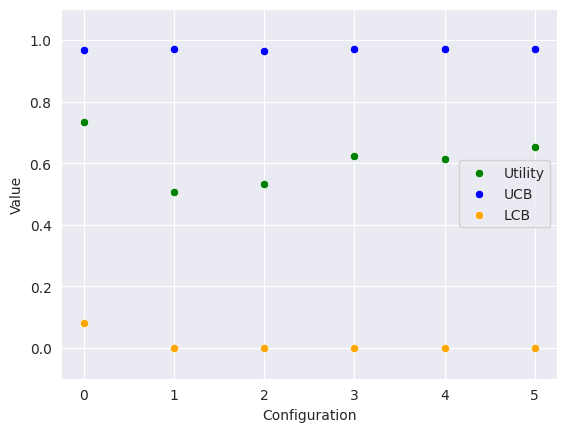

In [70]:
# sns.boxplot(x=[i for i in range(len(glob.glob(file_loc, recursive=False)))], y=utils, whis=list(pairs))
sns.scatterplot(x=[i for i in range(len(glob.glob(file_loc, recursive=False)))], y=utils, color="green", label="Utility")
sns.scatterplot(x=[i for i in range(len(glob.glob(file_loc, recursive=False)))], y=ucbs, color="blue", label="UCB")
sns.scatterplot(x=[i for i in range(len(glob.glob(file_loc, recursive=False)))], y=lcbs, color="orange", label="LCB")
plt.ylim(-0.1, 1.1)
plt.xlabel("Configuration")
plt.ylabel("Value")
plt.legend()